In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
import bambi as bmb
import arviz as az
from sklearn.preprocessing import StandardScaler

def remove_nulls_simple(data_subset, variables):
        # Drop rows where any of the specified variable columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=variables, ignore_index=True)
        # Subsets the cleaned dataframe back into only chosen variables
        vars_cleaned = data_subset_cleaned[variables]
        return vars_cleaned

def list_to_str(list_name):
    string = " + ".join(list_name)
    return string

pa_gs = pd.read_csv('data/pa_data.csv')
temps = pd.read_csv("data/pa_temps_supplement.csv")
#combining main csv dataset with supplementary temperature data csv
pa_gs = pa_gs.merge(temps, on=["station_id", "year"], how="left")

#limiting dataset to just time interval of interest
pa_gs = pa_gs[pa_gs['year'] >= 1960]
#dropping non-numeric columns
pa_gs = pa_gs.drop(['station_id', 'last_spring_frost_date', 'first_fall_frost_date', 'station_name','state'], axis=1)

def bayesian_model_standardized(data, target_var_name, cov_list):

    # takes in dataframe, desired target variable, and a list of covariates to be included in addition to time ("year") 
    # in a standardized bayesian heteroskedastic regression model.
    # outputs the model data tree, output data tree, standard deviations of each covariate, and model residuals.
    cov_str = list_to_str(cov_list)
    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data_cleaned = remove_nulls_simple(data, cov_list_target_var)
    
    sc = StandardScaler()
    data_standardized = sc.fit_transform(data_cleaned)
    data_standardized = pd.DataFrame(data_standardized)
    data_standardized.columns = data_cleaned.columns

    std = data_cleaned.std()
    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_str} + year",
                      f"sigma ~ {cov_str} + year")
    model = bmb.Model(formula, data=data_standardized, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = data_cleaned[target_var_name] - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values

    return model, output, std, resid

def bayesian_model_unstandardized(data, target_var_name, cov_list):

    # takes in dataframe, desired target variable, and a list of covariates to be included in addition to time ("year") 
    # in an unstandardized bayesian heteroskedastic regression model.
    # outputs the model data tree, output data tree, and model residuals.
    
    cov_str = list_to_str(cov_list)
    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data = remove_nulls_simple(data, cov_list_target_var)
    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_str} + year",
                      f"sigma ~ {cov_str} + year")
    model = bmb.Model(formula, data=data, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = data[target_var_name] - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values
    
    return model, output, resid

In [2]:
def calculated_v_empirical_std(data, cov_list, target_var_name, model, output):

    # calculates and plots the observed standard deviation of a certain set of covariates versus the modeled standard deviation

    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data_cleaned = remove_nulls_simple(data, cov_list_target_var)
    
    resids = data_cleaned['growing_season_length'].values - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values
    data_cleaned['resids'] = resids
    
    # compute predictions over chains/draws
    model.predict(output, kind="response_params") 
    # average over draws and then add to the data frame
    sigma_hats = output.posterior["sigma"].mean(("chain", "draw")).values  
    data_cleaned["sigma_hat"] = sigma_hats
    # aggregate by year
    sig_by_year = data_cleaned.groupby("year")["sigma_hat"].mean()
    # to get the empirical stds:
    empirical_stds_yearly  = data_cleaned.groupby("year")["resids"].std()
    fig, axs = plt.subplots(1,2, figsize=(8,4))
    axs[0].plot(sig_by_year, label = 'Bayesian Est. Uncertainty')
    axs[1].plot(empirical_stds_yearly, label = 'Yearly Model Residual STD')
    axs[0].legend()
    axs[1].legend()
    plt.show()

In [3]:
#defining covariate lists to be used for modeling
cov_list_1 = ['dtr_annual']
cov_list_2 = ['dtr_annual', 'tmean_spring', 'tmean_fall']
cov_list_3 = ['dtr_annual', 'tmean_spring', 'tmean_fall', 'tmax_annual']
cov_list_all = ['dtr_annual','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station', 'dtr_spring',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']
cov_list_all_minus_t = ['dtr_annual','latitude','longitude','oni_annual','nao_annual','pna_annual','amo_annual',
                        'sst_north_atlantic','pwat_station','dewpoint_station', 'soil_moisture_station',
                        'cloud_cover_station','evaporation_station', 'dtr_spring','sst_gulf_mexico',
                        'pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                        'cloud_cover_southeast_us','evaporation_southeast_us']

In [4]:
#running first three covariate lists (cov_list_1, cov_list_2, and cov_list_all)
#respectively, models correspond to MGSL1, MGSL2, and MGSL3 in paper
model_1, output_1, resid_1 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_list_1)
model_2, output_2, resid_2 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_list_2)
model_3, output_3, resid_3 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_list_all)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.144       31          100.12 draws/s       0:00:19    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.149       31          121.80 draws/s       0:00:16    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.153       63          112.31 draws/s       0:00:17    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.145       31          106.73 draws/s       0:00:18    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 26 seconds.


In [5]:
#running an extra model for cov_list_3. Not used in paper.
model_4, output_4, resid_4 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_list_3)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.232       15          453.21 draws/s       0:00:04    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.290       15          382.17 draws/s       0:00:05    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.319       15          400.53 draws/s       0:00:04    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.264       15          534.36 draws/s       0:00:03    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


In [6]:
#running another extra model for cov_list_all_minus_t. Not used in paper.
model_5, output_5, resid_5 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_list_all_minus_t)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.146       31          129.09 draws/s       0:00:15    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.129       31          110.38 draws/s       0:00:18    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.160       31          144.10 draws/s       0:00:13    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.155       31          115.40 draws/s       0:00:17    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.


In [7]:
#output summary for MGSL1
az.summary(output_1).head(6)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-306,35.3,-360,-250,3774,3297,1.00,0.57,0.42
dtr_annual,-10.805,0.233,-11,-10,4197,3314,1.00,0.0036,0.0026
year,0.2991,0.0173,0.27,0.33,3982,3273,1.00,0.00027,0.0002
sigma_Intercept,15.25,1.04,14,17,4939,3225,1.00,0.015,0.01
sigma_dtr_annual,-0.0425,0.0059,-0.052,-0.033,5437,3612,1.00,8.1e-05,5.8e-05
sigma_year,-0.00579,0.000513,-0.0066,-0.005,5028,3143,1.00,7.3e-06,4.9e-06


In [8]:
#determining bayesian credibility for mean of response and variance of response in MGSL1
gsl_posterior_1 = output_1.posterior['dtr_annual']
gsl_posterior_sigma_1 = output_1.posterior['sigma_dtr_annual']
gsl1_q05, gsl1_q95 = float(gsl_posterior_1.quantile(.05)), float(gsl_posterior_1.quantile(.95))
gsl1_s_q05, gsl1_s_q95 = float(gsl_posterior_sigma_1.quantile(.05)), float(gsl_posterior_sigma_1.quantile(.95))
print(f'5% DTR: {gsl1_q05}')
print(f'95% DTR: {gsl1_q95}')
print(f'5% Sigma_DTR: {gsl1_s_q05}')
print(f'95% Sigma_DTR: {gsl1_s_q95}')
print("Both DTR Trend and DTR Variance Trend are significant at 95%")

5% DTR: -11.190972170225313
95% DTR: -10.431081991889243
5% Sigma_DTR: -0.052228175317795535
95% Sigma_DTR: -0.03278382362544745
Both DTR Trend and DTR Variance Trend are significant at 95%


In [9]:
# output summary for MGSL2
az.summary(output_2).head(10)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-98.1,24.3,-140,-60,7057,3524,1.00,0.29,0.2
dtr_annual,-7.79,0.167,-8.1,-7.5,6371,3289,1.00,0.0021,0.0014
tmean_spring,3.591,0.158,3.3,3.8,4629,3289,1.00,0.0023,0.0016
tmean_fall,7.347,0.179,7.1,7.6,4324,3388,1.00,0.0027,0.002
year,0.1185,0.0121,0.099,0.14,7269,3625,1.00,0.00014,9.8e-05
sigma_Intercept,12.12,1,10,14,7494,3611,1.00,0.012,0.0084
sigma_dtr_annual,0.0311,0.0064,0.021,0.041,6049,3225,1.00,8.2e-05,5.8e-05
sigma_tmean_spring,-0.0231,0.0062,-0.033,-0.013,5230,3403,1.00,8.5e-05,6.1e-05
sigma_tmean_fall,0.0007,0.0068,-0.01,0.012,5440,3472,1.00,9.2e-05,6.2e-05
sigma_year,-0.00472,0.000502,-0.0055,-0.0039,7749,3498,1.00,5.7e-06,4.1e-06


In [10]:
#determining bayesian credibility for MGSL2 mean of response and variance of response
gsl_posterior_2 = output_2.posterior['tmean_spring']
gsl_posterior_sigma_2 = output_2.posterior['sigma_tmean_spring']
gsl2_q05, gsl2_q95 = float(gsl_posterior_2.quantile(.05)), float(gsl_posterior_2.quantile(.95))
gsl2_s_q05, gsl2_s_q95 = float(gsl_posterior_sigma_2.quantile(.05)), float(gsl_posterior_sigma_2.quantile(.95))
print(f'5% Spring TMean: {gsl2_q05}')
print(f'95% Spring TMean: {gsl2_q95}')
print(f'5% Sigma Spring TMean: {gsl2_s_q05}')
print(f'95% Sigma Spring TMean: {gsl2_s_q95}')
print("Both Mean Trend and Variance Trend are significant at 95%")

5% Spring TMean: 3.333140475996505
95% Spring TMean: 3.8538802848745157
5% Sigma Spring TMean: -0.03308075868354684
95% Sigma Spring TMean: -0.01277172912463071
Both Mean Trend and Variance Trend are significant at 95%


In [11]:
#output summary for Model 4, not used in paper.
az.summary(output_4).head(15)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-38,25.4,-78,2.6,4671,2878,1.00,0.37,0.26
dtr_annual,-9.749,0.25,-10,-9.4,2664,2636,1.00,0.0048,0.0035
tmean_spring,1.828,0.236,1.4,2.2,3199,2877,1.00,0.0042,0.0029
tmean_fall,5.311,0.263,4.9,5.7,2990,2869,1.00,0.0048,0.0035
tmax_annual,4.05,0.38,3.4,4.7,2486,2687,1.00,0.0077,0.0056
year,0.0872,0.0127,0.067,0.11,4706,2895,1.00,0.00019,0.00013
sigma_Intercept,9.36,1.02,7.7,11,4323,2808,1.00,0.016,0.012
sigma_dtr_annual,0.0465,0.0095,0.031,0.062,2644,2658,1.00,0.00018,0.00013
sigma_tmean_spring,-0.0099,0.0092,-0.025,0.0051,3164,2945,1.00,0.00016,0.00011
sigma_tmean_fall,0.0179,0.01,0.0021,0.033,2916,2860,1.00,0.00018,0.00014


In [12]:
# model output summary for model output 5. Not used in paper
az.summary(output_5)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,575,79,440,700,3243,3214,1.00,1.4,0.95
dtr_annual,-11.31,0.42,-12,-11,3385,3169,1.00,0.0071,0.005
latitude,-7.57,0.69,-8.7,-6.4,4150,3319,1.00,0.011,0.0076
longitude,1.602,0.231,1.2,2,4723,3694,1.00,0.0034,0.0024
oni_annual,-3.46,0.538,-4.3,-2.6,5957,3284,1.00,0.007,0.0048
nao_annual,-2.96,0.93,-4.5,-1.5,4211,3573,1.00,0.014,0.0098
pna_annual,4.26,0.99,2.6,5.8,7245,3151,1.00,0.012,0.0084
amo_annual,11.2,3.79,5.2,17,4076,3086,1.00,0.059,0.043
sst_north_atlantic,-15.2,3.5,-21,-9.6,3326,2712,1.00,0.061,0.045
pwat_station,-1.22,0.334,-1.8,-0.69,4070,3709,1.00,0.0053,0.0037


### RESULTS FROM FULL MODEL

In [13]:
#output summary for MGSL3
az.summary(output_3).head(50)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,127,69,18,240,3000,3095,1.00,1.3,0.88
dtr_annual,-9.51,0.46,-10,-8.8,2846,3145,1.00,0.0086,0.0061
tmean_spring,1.24,0.262,0.82,1.7,3647,3340,1.00,0.0043,0.0031
tmean_fall,5.759,0.284,5.3,6.2,3971,3210,1.00,0.0045,0.0031
latitude,-2.59,0.61,-3.6,-1.6,4101,3285,1.00,0.0095,0.0067
longitude,1.41,0.206,1.1,1.7,3343,2861,1.00,0.0036,0.0025
tmax_annual,3.62,0.45,2.9,4.3,3058,3171,1.00,0.0082,0.0058
oni_annual,0.12,0.499,-0.67,0.94,4945,3440,1.00,0.0071,0.0049
nao_annual,0.32,0.83,-1,1.7,3832,3206,1.00,0.013,0.0092
pna_annual,2.23,0.87,0.85,3.6,6106,3366,1.00,0.011,0.008


In [14]:
# model 3 priors
print(model_3)

       Formula: growing_season_length ~ dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + dewpoint_station + soil_moisture_station + cloud_cover_station + evaporation_station + dtr_spring + sst_gulf_mexico + pwat_southeast_us + dewpoint_2m_southeast_us + soil_moisture_southeast_us + cloud_cover_southeast_us + evaporation_southeast_us + year
                sigma ~ dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + dewpoint_station + soil_moisture_station + cloud_cover_station + evaporation_station + dtr_spring + sst_gulf_mexico + pwat_southeast_us + dewpoint_2m_southeast_us + soil_moisture_southeast_us + cloud_cover_southeast_us + evaporation_southeast_us + year
        Family: gaussian
          Link: mu = identity
                sigma = log
  Observations:

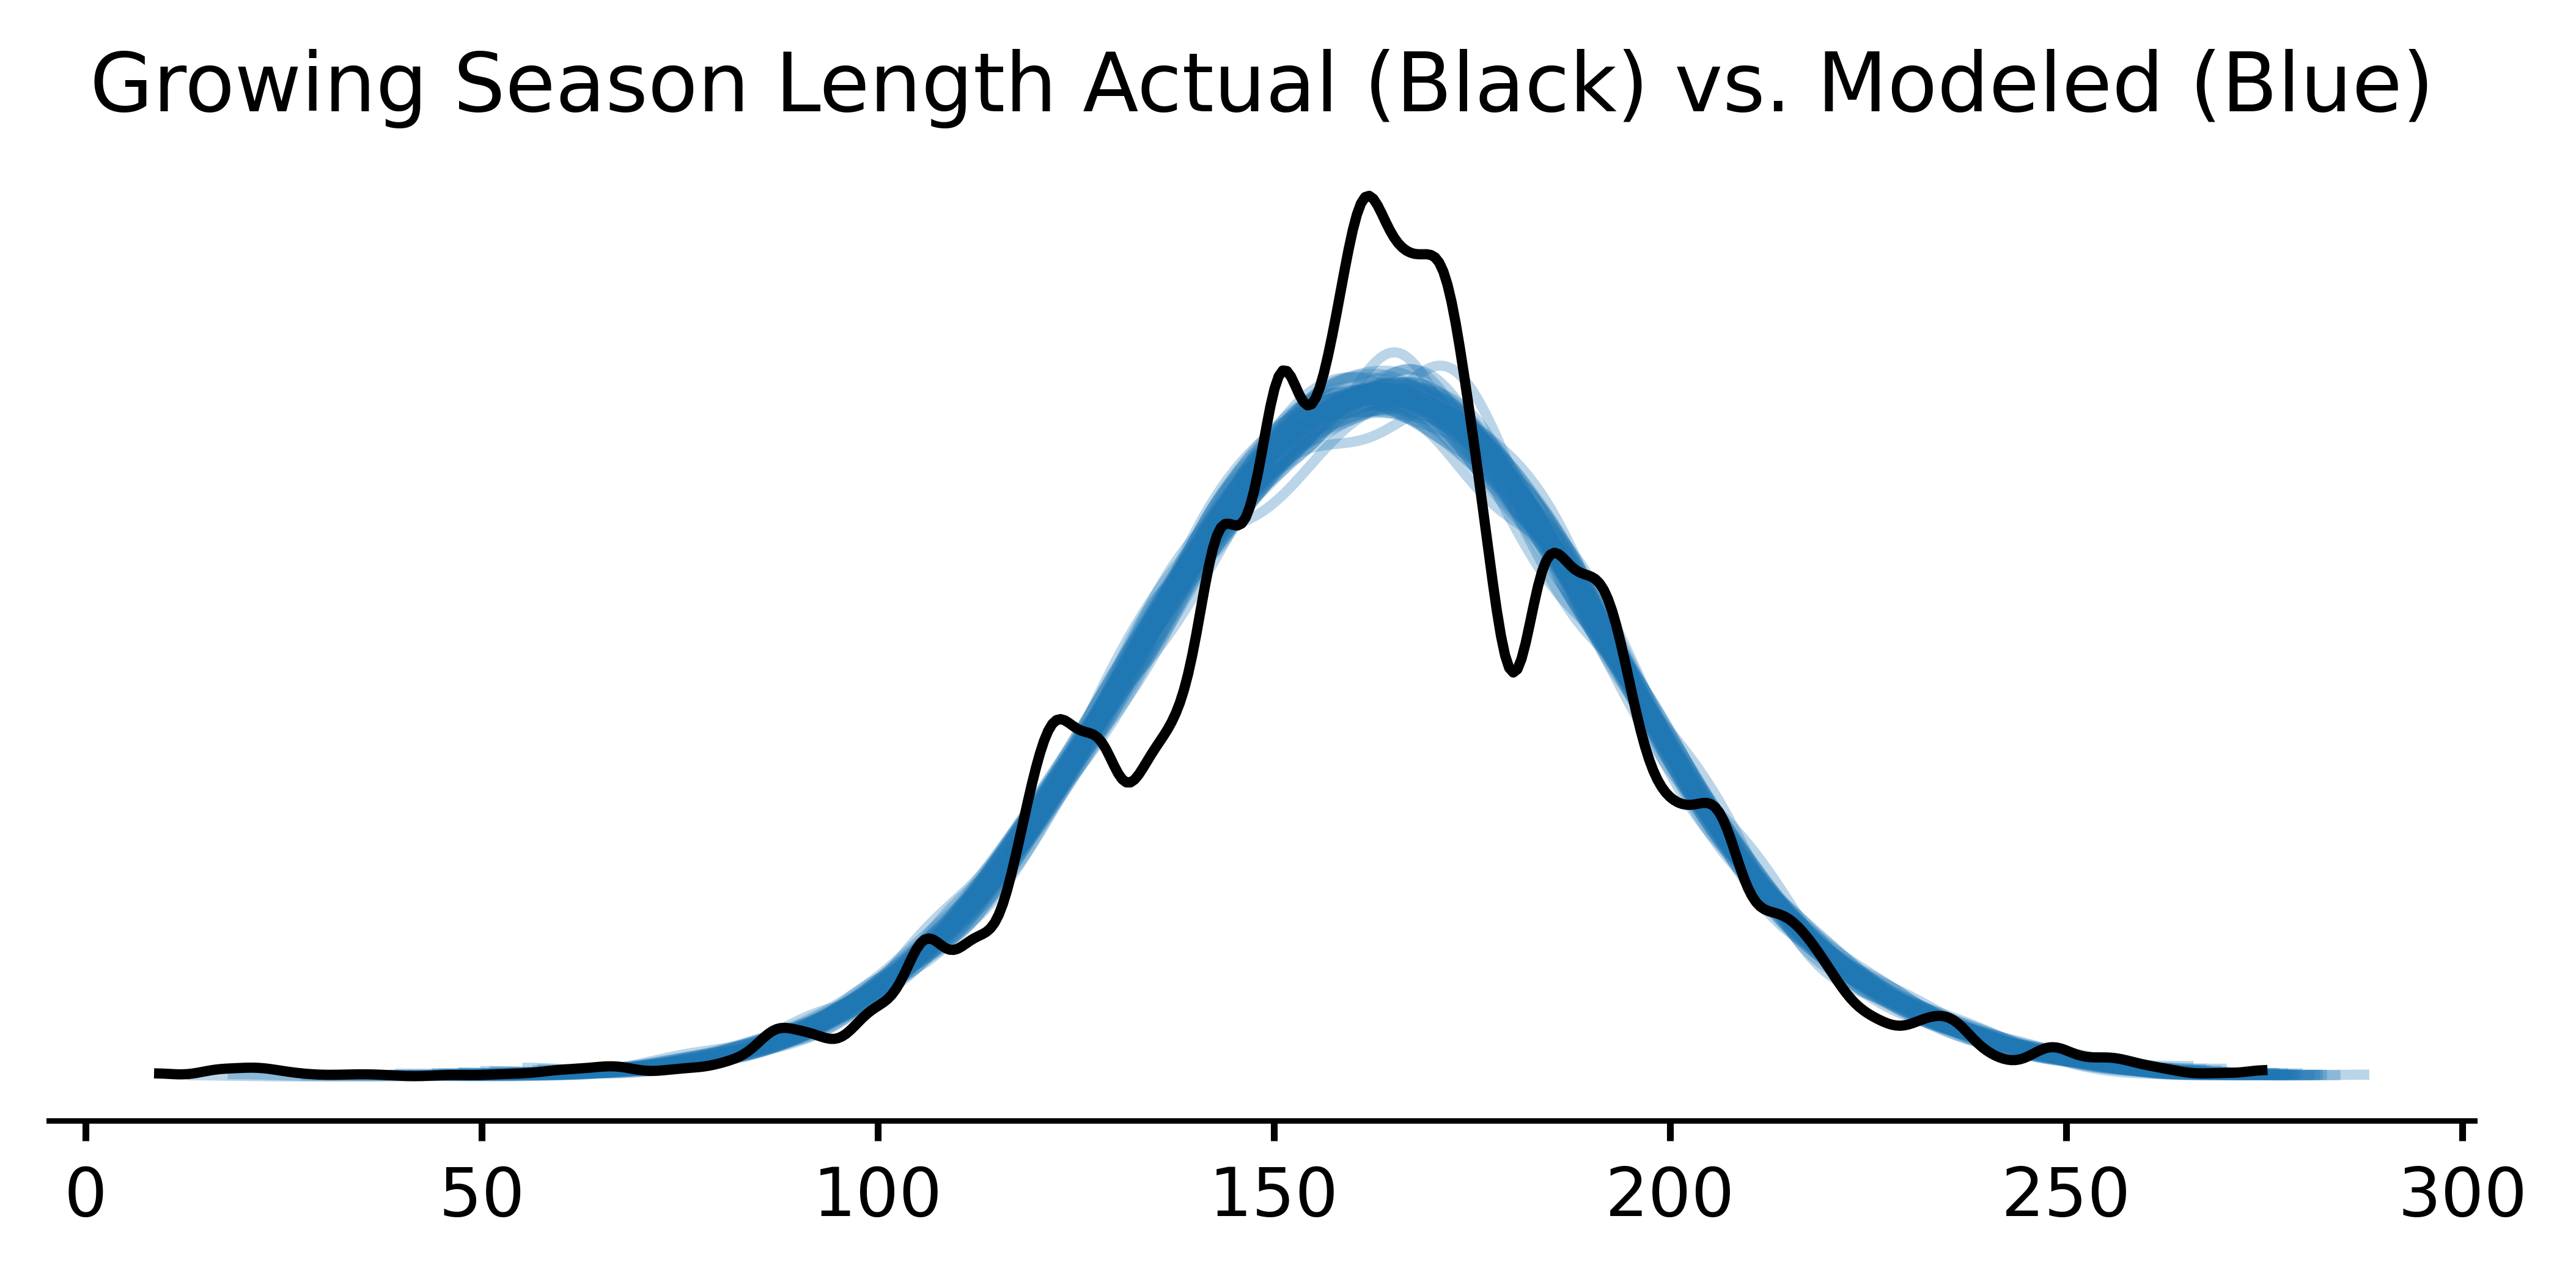

In [34]:
# plotted actual GSL vs Modeled GSL
model_3.predict(output_3, kind="response")
az.plot_ppc_dist(output_3)
plt.title("Growing Season Length Actual (Black) vs. Modeled (Blue)")
plt.rcParams['figure.dpi'] = 800
plt.rcParams['savefig.dpi'] = 800
plt.show()

In [35]:
# Credibile Interval Check (if doesn't include 0, "significant" in bayesian way)
print('95% Bayesian Significance Check')
posteriors_dict = {}
cov_list_all_yr = cov_list_all + ['year']
for cov in cov_list_all_yr:
    posterior = output_3.posterior[f'{cov}']
    q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
    posteriors_dict[cov] = [q05, q95, q05 <= 0 <= q95]

posteriors_df = pd.DataFrame(posteriors_dict)
post_df_names = {0:'q05', 1:'q95', 2: "crosses 0"}
posteriors_df = posteriors_df.rename(index = post_df_names)
posteriors_df[['dtr_annual','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station']]

95% Bayesian Significance Check


,dtr_annual,tmean_spring,tmean_fall,latitude,longitude,tmax_annual,oni_annual,nao_annual,pna_annual,amo_annual,sst_north_atlantic,pwat_station,dewpoint_station,soil_moisture_station,cloud_cover_station,evaporation_station
q05,-10.246661,0.820694,5.313373,-3.590654,1.073671,2.858203,-0.683773,-1.102278,0.764193,-2.583466,-8.530632,-1.909658,-1.901562,-10.187097,-43.007957,2.012101
q95,-8.76839,1.686244,6.199964,-1.55211,1.747461,4.355778,0.926584,1.71483,3.760115,9.052148,2.260387,-0.890733,-0.054482,13.439145,-11.198574,7.258234
crosses 0,False,False,False,False,False,False,True,True,False,True,True,False,False,True,False,False


In [32]:
posteriors_df[['dtr_spring','sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us',
               'soil_moisture_southeast_us','cloud_cover_southeast_us','evaporation_southeast_us', 'year']]

,dtr_spring,sst_gulf_mexico,pwat_southeast_us,dewpoint_2m_southeast_us,soil_moisture_southeast_us,cloud_cover_southeast_us,evaporation_southeast_us,year
q05,-0.772359,-2.784002,1.253722,-6.583879,1.483791,-151.579073,-18.737924,0.150637
q95,0.335896,4.006739,3.083379,-2.200218,283.965164,-90.386603,-9.200306,0.274726
crosses 0,True,True,False,False,False,False,False,False


In [23]:
pa_gs_60_61 = pa_gs[pa_gs['year'].between(1960,1961)]
pa_gs_24_25 = pa_gs[pa_gs['year'].between(2024,2025)]
print(f'1960 GSL Variance: {pa_gs_60_61['growing_season_length'].var()}')
print(f'1960 GSL Variance: {pa_gs_24_25['growing_season_length'].var()}')
pct_chg_gsl_var = (pa_gs_24_25['growing_season_length'].var() - pa_gs_60_61['growing_season_length'].var()) / pa_gs_60_61['growing_season_length'].var()
print(f'Percent Change in GSL Variability, observed: {(pct_chg_gsl_var * 100).round(2)}%')

1960 GSL Variance: 1165.1675274988042
1960 GSL Variance: 571.2638544251448
Percent Change in GSL Variability, observed: -50.97%


In [24]:
print(pa_gs[pa_gs['year']==1960]['growing_season_length'].std())

25.67157347341828


## DTR Trend and Variability Analysis

In [37]:
# model with target variable of dtr, based only on year. corresponds to MDTR1 in paper.
formula_dtr = bmb.Formula(f"dtr_annual ~  year",
                      f"sigma ~ year")
model_dtr = bmb.Model(formula_dtr, data=pa_gs, dropna = True)
output_dtr = model_dtr.fit(idata_kwargs={'log_likelihood':True})

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.986       3           1497.26 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.862       3           2431.45 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           1.146       3           2420.16 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           1.089       3           2603.27 draws/s      0:00:00    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [38]:
# output summary of MDTR1
az.summary(output_dtr)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,36.61,1.77,34,39,4899,3432,1.00,0.025,0.018
year,-0.01254,0.00089,-0.014,-0.011,4913,3417,1.00,1.3e-05,8.8e-06
sigma_Intercept,10.31,0.97,8.8,12,7813,3603,1.00,0.011,0.0076
sigma_year,-0.00502,0.00049,-0.0058,-0.0042,7803,3654,1.00,5.6e-06,3.8e-06


In [39]:
# bayesian credibilty check for MDTR1
dtr_posterior_yr = output_dtr.posterior['year']
dtr_posterior_sigma_yr = output_dtr.posterior['sigma_year']
dtr_yr_q05, dtr_yr_q95 = float(dtr_posterior_yr.quantile(.05)), float(dtr_posterior_yr.quantile(.95))
dtr_syr_q05, dtr_syr_q95 = float(dtr_posterior_sigma_yr.quantile(.05)), float(dtr_posterior_sigma_yr.quantile(.95))
print(f'5% Year: {dtr_yr_q05}')
print(f'95% Year: {dtr_yr_q95}')
print(f'5% Sigma_Year: {dtr_syr_q05}')
print(f'95% Sigma_Year: {dtr_syr_q95}')
print("Both DTR Trend and DTR Variance Trend are significant at 95%")

5% Year: -0.014000377121756027
95% Year: -0.011075490878258784
5% Sigma_Year: -0.005811807672557643
95% Sigma_Year: -0.0042184567683426506
Both DTR Trend and DTR Variance Trend are significant at 95%


In [40]:
# Modeling DTR based on list of covariates. corresponds to MDTR2 in paper.
dtr_cov_str_all = 'tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + dewpoint_station + soil_moisture_station + cloud_cover_station + evaporation_station + sst_gulf_mexico + pwat_southeast_us + dewpoint_2m_southeast_us + soil_moisture_southeast_us + cloud_cover_southeast_us + evaporation_southeast_us'
formula_dtr_all = bmb.Formula(f"dtr_annual ~  {dtr_cov_str_all} + year",
                      f"sigma ~ {dtr_cov_str_all} + year")
model_dtr_all = bmb.Model(formula_dtr_all, data=pa_gs, dropna = True)
output_dtr_all = model_dtr_all.fit(idata_kwargs={'log_likelihood':True})

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.178       31          137.70 draws/s       0:00:14    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.111       31          122.24 draws/s       0:00:16    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.173       31          109.63 draws/s       0:00:18    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.138       31          146.89 draws/s       0:00:13    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 24 seconds.


In [41]:
# Output summary of MDTR2
az.summary(output_dtr_all)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,2.4,2.92,-2.2,7.1,3207,3179,1.00,0.052,0.036
tmean_spring,-0.5457,0.0105,-0.56,-0.53,3386,3113,1.00,0.00018,0.00012
tmean_fall,-0.5978,0.0102,-0.61,-0.58,4959,3192,1.00,0.00014,0.00011
latitude,0.0783,0.0278,0.035,0.12,4648,3141,1.00,0.00041,0.00029
longitude,-0.1304,0.0088,-0.14,-0.12,3802,3196,1.00,0.00014,0.0001
tmax_annual,1.3237,0.0137,1.3,1.3,3652,2921,1.00,0.00023,0.00016
oni_annual,0.0677,0.0225,0.031,0.1,4181,3389,1.00,0.00035,0.00024
nao_annual,-0.214,0.0365,-0.27,-0.16,3668,3241,1.00,0.0006,0.00043
pna_annual,0.036,0.0433,-0.034,0.1,4533,3010,1.00,0.00064,0.00044
amo_annual,1.87,0.131,1.7,2.1,3787,3136,1.00,0.0021,0.0015


In [42]:
# MDTR2 Bayesian Credibility Check
dtr_2_posterior_yr = output_dtr_all.posterior['year']
dtr_2_posterior_sigma_yr = output_dtr_all.posterior['sigma_year']
dtr_2_yr_q05, dtr_2_yr_q95 = float(dtr_2_posterior_yr.quantile(.05)), float(dtr_2_posterior_yr.quantile(.95))
dtr_2_syr_q05, dtr_2_syr_q95 = float(dtr_2_posterior_sigma_yr.quantile(.05)), float(dtr_2_posterior_sigma_yr.quantile(.95))
print(f'5% Year: {dtr_2_yr_q05}')
print(f'95% Year: {dtr_2_yr_q95}')
print(f'5% Sigma_Year: {dtr_2_syr_q05}')
print(f'95% Sigma_Year: {dtr_2_syr_q95}')
print("Both DTR Trend and DTR Variance Trend are significant at 95%")

5% Year: 0.0068569667968627675
95% Year: 0.012416337086123563
5% Sigma_Year: 0.006175020226475838
95% Sigma_Year: 0.01161229738170203
Both DTR Trend and DTR Variance Trend are significant at 95%
